In [2]:
import numpy as np

z = np.loadtxt( "quazars.csv" , delimiter=",")

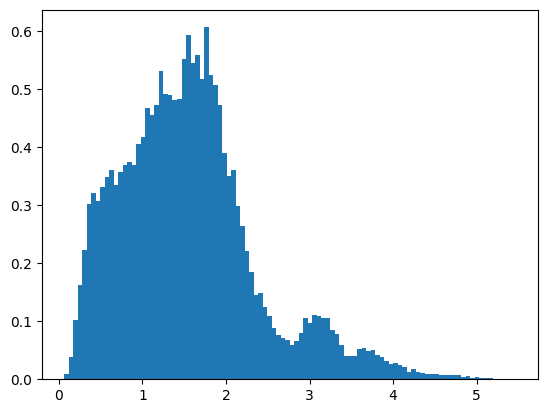

In [5]:
import matplotlib.pyplot as plt

plt.hist(z, bins = 100 , density=True);

In [15]:
from numpy import random
from scipy.optimize import brentq
from scipy.stats import uniform


def hit_or_miss( dataset: np.ndarray , N_samples: int , bins: int):
    sim_data = []
    upper_limit = 1
    count, edges = np.histogram( dataset , bins = bins , density = True)
    if count[np.argmax(count)] < 0.5: upper_limit = 0.5
    while len(sim_data) != N_samples:
        x_sim = random.random() * (edges[-1] - edges[0]) - edges[0]
        y_sim = random.random()*upper_limit
        bin_index = np.digitize(x_sim, edges) - 1
        if bin_index >= 0 and bin_index < len(count) and y_sim <= count[bin_index]:
            sim_data.append(x_sim)
    return sim_data

def analytical_cdf( dataset , start , stop):
    interval = dataset[(dataset>start) & (dataset<stop)]
    if not len(interval): return 0
    count, edges = np.histogram(interval , density=True)
    return np.sum([count[i]*np.diff(edges)[i] for i in range(len(count))])



def inverse_cdf_numerical( dataset: np.ndarray , N_samples: int, bins:int):
    
    eps = np.asarray(uniform.rvs(size=N_samples), dtype=float)

    cdf = lambda h: analytical_cdf( dataset , 0 , h)
    samples = [ brentq(lambda h: cdf(h)-e, 0 , max(dataset)+0.5) for e in eps]
    return samples

In [ ]:
plt.hist( z , density=True,histtype='step' , bins = 100)
plt.hist( hit_or_miss( z , len(z) , bins=100) , density=True,histtype='step' , bins = 100)
plt.hist( inverse_cdf_numerical( z , len(z) , bins = 100) , density=True,histtype='step' , bins = 100)